In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score, roc_auc_score, f1_score

import torch 
from torch import nn
from PIL import Image
from torchvision import transforms

# Deep Visual Style Recognition Across Domains

### A deep learning study of cross-domain art-versus-photo classification

## Abstract

This project extends a previous classical machine learning study on visual style classification by moving from handcrafted visual descriptors to deep learned representations. The earlier Visual Style Classification with Handcrafted Features project showed that handcrafted features such as HOG, LBP, and Gabor filters can achieve strong performance in a constructed WikiArt-versus-Unsplash classification setting. However, the analysis also revealed an important limitation: source-domain bias. A metadata-only diagnostic showed that technical image properties can strongly separate the datasets, meaning that high classification performance may partly reflect dataset-specific artefacts rather than generalizable visual style patterns.

This project addresses that limitation by using a multi-source dataset design and deep learning models to evaluate whether learned visual representations generalize better across domains. The project compares a convolutional neural network trained from scratch with transfer learning based on pretrained CNN architectures, with a primary focus on ResNet18. The task remains a binary classification problem between artistic images and real-world photographic images, but the data is expanded to include multiple independent sources for each class.

Model performance is evaluated under both random stratified splits and stricter cross-dataset splits, where models are trained on one pair of art/photo sources and tested on unseen sources. This makes it possible to distinguish between closed-domain performance and cross-domain generalization. In addition, metadata-only diagnostics, learning curves, confusion matrices, embedding visualizations, and Grad-CAM analysis are used to interpret model behaviour and inspect whether the models rely on meaningful visual structure or dataset-specific artefacts.

The central goal is not only to improve classification performance, but to investigate whether deep learned visual representations can generalize beyond the original source-biased experimental setup and provide a stronger basis for art-versus-photo classification across domains.

## Introduction

Deep learning has become the dominant approach in modern computer vision because convolutional neural networks can learn visual representations directly from image data. Unlike classical machine learning pipelines, which depend on manually designed features such as entropy, edge density, HOG, LBP, or Gabor filters, deep learning models can learn hierarchical representations of visual structure from pixels.

This project builds directly on the findings of the previous Visual Style Classification with Handcrafted Features project, a classical machine learning study focused on distinguishing artistic images from natural photographs using handcrafted visual descriptors. That project demonstrated that compact texture- and frequency-based descriptors can perform surprisingly well. In particular, LBP and Gabor feature fusion achieved strong classification performance while using far fewer dimensions than HOG. However, the project also identified a major limitation: the WikiArt-versus-Unsplash dataset construction introduced source-domain bias. The classifier may have learned technical differences between datasets rather than purely general visual differences between artwork and photography.

The present project therefore asks a new question: can deep learned representations improve cross-domain generalization in visual style classification?

To answer this question, the project uses a multi-source dataset design. The artistic class is represented by images from WikiArt and ArtBench, while the photographic class is represented by images from Places365 and a COCO subset. This design reduces dependence on a single source per class and enables cross-dataset evaluation. Models are first evaluated on a standard random stratified split and then on stricter cross-dataset splits, where training and testing sources are intentionally separated.

The project compares three main modelling approaches: a metadata-only baseline for bias diagnostics, a CNN trained from scratch, and transfer learning using a pretrained ResNet18 model. The final analysis focuses not only on accuracy and ROC-AUC, but also on generalization gaps, error patterns, feature embeddings, and qualitative Grad-CAM explanations.

This project is therefore not simply a deep learning replacement for the previous ML pipeline. It is a continuation of the same research question under a stronger experimental design: from handcrafted representations in a closed domain to learned representations evaluated across domains.

## Research Question and Hypotheses

The previous handcrafted-feature project showed that strong classification performance can be achieved in a closed WikiArt-versus-photo setup. However, it also revealed that dataset-specific technical artefacts may strongly influence the task. Therefore, the central question of this project is not only whether a deep learning model can classify artistic and photographic images, but whether it can generalize across unseen visual data sources.

The main research question is:

**Can deep learned visual representations improve cross-dataset generalization in art-versus-photo classification compared to a source-biased handcrafted-feature setup?**

This question is evaluated through the following hypotheses:

**H1 — Metadata bias hypothesis:**  
Technical image metadata such as resolution, aspect ratio, file size, and file format may contain strong source-domain signal. If metadata-only models achieve high performance, random split results must be interpreted carefully.

**H2 — Transfer learning hypothesis:**  
A pretrained CNN, especially ResNet18, is expected to outperform a CNN trained from scratch because it starts from general visual representations learned from large-scale image data.

**H3 — Cross-dataset generalization hypothesis:**  
Random stratified split performance is expected to be higher than cross-dataset performance. Cross-dataset evaluation is therefore used as a stricter test of whether the model learns transferable visual structure rather than source-specific artefacts.

**H4 — Interpretability hypothesis:**  
Grad-CAM and error analysis can provide qualitative evidence about whether model decisions are influenced by meaningful visual regions or by dataset-specific visual artefacts.

## Dataset Design

The project uses a balanced multi-source dataset design. Instead of assigning each class to a single dataset source, each class is represented by two independent image sources. This is important because if one class comes from only one dataset and the other class comes from only one different dataset, the classification task may become a dataset-identification task rather than a visual-style classification task.

The artistic class consists of:

- **WikiArt** — artistic images from multiple artists, periods, and styles;
- **ArtBench** — a structured artwork benchmark dataset with multiple artistic styles.

The photographic class consists of:

- **Places365** — real-world scene photographs;
- **COCO** — real-world photographic images from everyday scenes.

For the initial full experiment, the project samples 10,000 images from each source dataset, resulting in 40,000 images in total:

| Source dataset | Class | Number of images |
|---|---:|---:|
| WikiArt | art | 10,000 |
| ArtBench | art | 10,000 |
| Places365 | photo | 10,000 |
| COCO | photo | 10,000 |

This produces a balanced binary classification dataset with 20,000 artistic images and 20,000 photographic images.

The goal of this design is not to remove all possible bias, which is unrealistic for real-world image datasets, but to reduce dependence on a single source per class and make cross-dataset evaluation possible.

## Dataset Manifest and Split Strategy

A central dataset manifest is created to make the data selection and split assignment reproducible. The manifest stores the image path, binary label, class name, source dataset, original metadata where available, and the split assignment for each experiment.

The manifest contains the following key columns:

| Column | Meaning |
|---|---|
| `image_path` | Relative path to the image file |
| `label` | Binary target: 1 for art, 0 for photo |
| `class_name` | Human-readable class name: art or photo |
| `source_dataset` | Original dataset source: WikiArt, ArtBench, Places365, or COCO |
| `original_split` | Original train/test split when available, mainly for ArtBench |
| `original_style` | Original ArtBench style category when available |
| `split_random` | Standard random train/validation/test split |
| `split_cross_a` | Cross-dataset split A |
| `split_cross_b` | Cross-dataset split B |

Three split strategies are used.

### Random stratified split

The random split mixes all four source datasets while preserving class and source balance. It provides a standard closed-domain benchmark.

### Cross-dataset split A

In this setting, the model is trained on WikiArt and Places365 and tested on ArtBench and COCO.

| Role | Sources |
|---|---|
| Train/validation | WikiArt + Places365 |
| Test | ArtBench + COCO |

### Cross-dataset split B

In this setting, the model is trained on ArtBench and COCO and tested on WikiArt and Places365.

| Role | Sources |
|---|---|
| Train/validation | ArtBench + COCO |
| Test | WikiArt + Places365 |

The cross-dataset splits are the central evaluation setup of this project. They test whether models can generalize to unseen sources instead of only performing well when the same dataset sources appear in both training and test data.

## Metadata Bias Diagnostic

Before training deep learning models, the project performs a metadata-only diagnostic. The purpose of this step is to test whether technical image properties alone can predict the class label or the source dataset.

The metadata features include:

- image width;
- image height;
- aspect ratio;
- file size;
- log-transformed file size;
- megapixels;
- number of channels;
- landscape/portrait/square indicators;
- file extension.

These features do not describe semantic image content. They only describe technical properties of the image files. Therefore, strong metadata-only performance indicates possible source-domain bias.

The metadata-only results show that the random split contains a very strong technical signal. A Random Forest classifier trained only on metadata reaches very high performance for art-versus-photo classification under the random split. The same metadata features also predict the source dataset with very high accuracy.

However, the cross-dataset metadata experiments behave very differently. When the metadata model is trained on one pair of sources and tested on another pair, performance collapses. This suggests that the metadata model is not learning a stable art-versus-photo distinction, but source-specific technical patterns.

This finding is important for the rest of the project. It shows that random split performance alone is not sufficient. Deep learning models must also be evaluated under cross-dataset splits to test whether they learn transferable visual representations rather than source-specific artefacts.

### Metadata Diagnostic Results

The metadata-only diagnostic reveals a strong technical source-domain signal in the dataset. Under the random stratified split, a Random Forest classifier trained only on technical image metadata reaches very high performance for art-versus-photo classification.

This result is important because the model does not use image content in the usual visual sense. It does not receive learned CNN features, handcrafted visual descriptors, or semantic information. It only receives technical properties such as image resolution, aspect ratio, file size, number of channels, and file extension.

The random split result therefore shows that technical image properties are strongly correlated with the class labels when all source datasets are mixed across train and test partitions. In this setting, metadata alone is sufficient to separate art and photo images with very high performance.

However, the cross-dataset splits show a very different pattern. When the metadata model is trained on one pair of art/photo sources and tested on a different pair of unseen sources, performance collapses. This means that the metadata model is not learning a stable art-versus-photo distinction. Instead, it learns source-specific technical patterns that do not transfer consistently across datasets.

This finding supports the first hypothesis of the project: random split performance can be strongly influenced by source-domain artefacts and must therefore be interpreted carefully.

### Source-Level Metadata Distribution

To understand why the metadata-only model behaves this way, it is useful to inspect the technical properties of each source dataset separately. The most important source-level differences are expected to appear in features such as image resolution, megapixels, and file size.

In the current dataset design, the four sources do not have identical technical distributions. ArtBench and Places365 contain many small 256×256 images, while WikiArt often contains much larger artwork files. COCO images have a different photographic resolution distribution. These differences create technical signatures that can be learned by a metadata-only classifier.

This explains why source-dataset classification is also very strong. The model can identify whether an image comes from WikiArt, ArtBench, Places The model can identify whether an image comes from WikiArt, ArtBench, Places365, or COCO using metadata alone. Therefore, source identity is technically visible in the dataset.

### Explaining the Cross-Dataset Inversion

The most important result is not only that metadata performance drops under cross-dataset evaluation, but that it can become almost perfectly inverted.

This happens because the technical relationship between class and source changes across the cross-dataset splits.

In cross-dataset split B, the model is trained on ArtBench and COCO. In this training pair, ArtBench represents the art class and often contains small 256×256 images, while COCO represents the photo class and has a different resolution and file-size distribution. A metadata-only model can therefore learn a rule similar to:

**small technical size → art**
**larger technical size → photo**

However, in the test pair for cross-dataset split B, the sources are WikiArt and Places365. WikiArt represents the art class but often contains much larger images, while Places365 represents the photo class and contains many small 256×256 scene images. This reverses the technical relationship learned during training.

As a result, the metadata model applies a source-specific rule that becomes systematically wrong on the unseen test sources. This explains why the cross-dataset metadata result can reach zero accuracy and zero ROC-AUC: the model is not randomly guessing, but applying an inverted technical pattern.

This is a strong demonstration of source-domain bias. It shows that a model can perform extremely well under a random split while completely failing under a source-separated evaluation.

### Implication for Deep Learning Experiments

The metadata diagnostic motivates the rest of the project. Since technical metadata alone can almost perfectly separate classes under a random split, deep learning models should not be evaluated only under random train-test conditions.

The key question is whether CNN-based visual representations can generalize better than metadata-only patterns when evaluated on unseen source datasets.

Image resizing and normalization will remove some direct metadata signals, such as original image resolution and file size, from the model input. However, this does not guarantee that all source-domain bias is removed. Dataset-specific visual artefacts may still remain, including compression patterns, borders, color distributions, cropping style, texture sharpness, and source-specific image quality.

For this reason, the main evaluation of the deep learning models must include cross-dataset splits. Random split performance will be treated as a closed-domain benchmark, while cross-dataset performance will be treated as the stronger test of visual generalization.

In [3]:
PROJECT_ROOT = Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

metadata_features = pd.read_csv(
    PROCESSED_DIR / "metadata_features.csv"
)

metadata_results = pd.read_csv(
    PROCESSED_DIR / "metadata_bias_results.csv"
)

metadata_feature_importance = pd.read_csv(
    PROCESSED_DIR / "metadata_bias_feature_importance.csv"
)

metadata_results

,experiment,target,split_column,model,train_size,test_size,accuracy,auc,precision_macro,recall_macro,f1_macro
0,Metadata-only art/photo classification - rando...,art_photo_label,split_random,Dummy Classifier,28000,6000,0.5000,0.5000,0.2500,0.5000,0.3333
1,Metadata-only art/photo classification - rando...,art_photo_label,split_random,Random Forest,28000,6000,0.9683,0.9901,0.9683,0.9683,0.9683
2,Metadata-only art/photo classification - cross A,art_photo_label,split_cross_a,Dummy Classifier,16000,20000,0.5000,0.5000,0.2500,0.5000,0.3333
3,Metadata-only art/photo classification - cross A,art_photo_label,split_cross_a,Random Forest,16000,20000,0.3841,0.0035,0.2172,0.3841,0.2775
4,Metadata-only art/photo classification - cross B,art_photo_label,split_cross_b,Dummy Classifier,16000,20000,0.5000,0.5000,0.2500,0.5000,0.3333
5,Metadata-only art/photo classification - cross B,art_photo_label,split_cross_b,Random Forest,16000,20000,0.0000,0.0000,0.0000,0.0000,0.0000
6,Metadata-only source dataset classification,source_dataset,split_random,Dummy Classifier,28000,6000,0.2500,0.5000,0.0625,0.2500,0.1000
7,Metadata-only source dataset classification,source_dataset,split_random,Random Forest,28000,6000,0.9683,0.9934,0.9683,0.9683,0.9683


In [4]:
source_metadata_summary = (
    metadata_features
    .groupby(["source_dataset", "class_name"])
    .agg(
        image_count=("image_path", "count"),
        median_width=("width", "median"),
        median_height=("height", "median"),
        median_aspect_ratio=("aspect_ratio", "median"),
        median_file_size_kb=("file_size_kb", "median"),
        median_megapixels=("megapixels", "median"),
    )
    .reset_index()
    .sort_values(["class_name", "source_dataset"])
)

source_metadata_summary


,source_dataset,class_name,image_count,median_width,median_height,median_aspect_ratio,median_file_size_kb,median_megapixels
0,artbench,art,10000,256.0,256.0,1.000000,31.302246,0.065536
3,wikiart,art,10000,1382.0,1447.5,0.954750,380.427734,2.545644
1,coco,photo,10000,640.0,480.0,1.333333,150.409668,0.273920
2,places365,photo,10000,256.0,256.0,1.000000,13.112305,0.065536


In [5]:
top_metadata_importance = (
    metadata_feature_importance
    .sort_values(
        ["experiment", "importance"],
        ascending=[True, False],
    )
    .groupby("experiment")
    .head(8)
    .reset_index(drop=True)
)

top_metadata_importance

,experiment,target,split_column,model,feature,importance
0,Metadata-only art/photo classification - cross A,art_photo_label,split_cross_a,Random Forest,megapixels,0.203426
1,Metadata-only art/photo classification - cross A,art_photo_label,split_cross_a,Random Forest,file_size_kb,0.195215
2,Metadata-only art/photo classification - cross A,art_photo_label,split_cross_a,Random Forest,log_file_size_kb,0.190070
3,Metadata-only art/photo classification - cross A,art_photo_label,split_cross_a,Random Forest,height,0.159902
4,Metadata-only art/photo classification - cross A,art_photo_label,split_cross_a,Random Forest,width,0.156701
5,Metadata-only art/photo classification - cross A,art_photo_label,split_cross_a,Random Forest,is_square,0.064289
6,Metadata-only art/photo classification - cross A,art_photo_label,split_cross_a,Random Forest,is_portrait,0.013694
7,Metadata-only art/photo classification - cross A,art_photo_label,split_cross_a,Random Forest,aspect_ratio,0.011865
8,Metadata-only art/photo classification - cross B,art_photo_label,split_cross_b,Random Forest,megapixels,0.275137
9,Metadata-only art/photo classification - cross B,art_photo_label,split_cross_b,Random Forest,width,0.188506


In [6]:
NUMERIC_METADATA_COLUMNS = [
    "width",
    "height",
    "aspect_ratio",
    "file_size_kb",
    "log_file_size_kb",
    "megapixels",
    "channels",
    "is_landscape",
    "is_portrait",
    "is_square",
]

CATEGORICAL_METADATA_COLUMNS = [
    "file_extension",
]


def build_metadata_matrix(df):
    numeric_features = df[NUMERIC_METADATA_COLUMNS].copy()

    categorical_features = pd.get_dummies(
        df[CATEGORICAL_METADATA_COLUMNS],
        dummy_na=False,
        dtype=float,
    )

    return pd.concat(
        [
            numeric_features.reset_index(drop=True),
            categorical_features.reset_index(drop=True),
        ],
        axis=1,
    )


X_metadata = build_metadata_matrix(metadata_features)

cross_b_train_mask = metadata_features["split_cross_b"] == "train"
cross_b_test_mask = metadata_features["split_cross_b"] == "test"

X_train_cross_b = X_metadata.loc[cross_b_train_mask].copy()
X_test_cross_b = X_metadata.loc[cross_b_test_mask].copy()

y_train_cross_b = metadata_features.loc[
    cross_b_train_mask,
    "label",
].copy()

y_test_cross_b = metadata_features.loc[
    cross_b_test_mask,
    "label",
].copy()

metadata_rf_cross_b = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
)

metadata_rf_cross_b.fit(
    X_train_cross_b,
    y_train_cross_b,
)

y_pred_cross_b = metadata_rf_cross_b.predict(
    X_test_cross_b
)

cross_b_confusion_matrix = pd.DataFrame(
    confusion_matrix(
        y_test_cross_b,
        y_pred_cross_b,
        labels=[0, 1],
    ),
    index=["True photo", "True art"],
    columns=["Predicted photo", "Predicted art"],
)

cross_b_confusion_matrix

,Predicted photo,Predicted art
True photo,0,10000
True art,10000,0


The confusion matrix confirms that the cross-dataset failure is not a random collapse. The metadata-only classifier systematically transfers a technical rule learned from the training sources to a test setting where the relationship between metadata and class is reversed. This produces an almost perfectly inverted prediction pattern.

This result strengthens the motivation for cross-dataset evaluation. A model can appear extremely strong under a random split while learning patterns that do not represent transferable art-versus-photo visual structure.

## Deep Learning Methodology

After establishing the presence of metadata and source-domain bias, the project moves to deep learning models trained directly on image data. The goal of this stage is not only to improve classification performance, but to evaluate whether learned visual representations are more transferable across dataset sources than technical metadata patterns.

All images are loaded from the central dataset manifest. This ensures that the same image selection and split definitions are used consistently across all deep learning experiments. The manifest-based design also prevents accidental differences between models caused by reading folders independently or re-sampling the data.

The deep learning pipeline follows a supervised binary classification setup:

| Component            | Description                                                      |
| -------------------- | ---------------------------------------------------------------- |
| Input                | RGB image                                                        |
| Target               | Binary label: art or photo                                       |
| Positive class       | art                                                              |
| Negative class       | photo                                                            |
| Main random split    | Balanced random train/validation/test split                      |
| Cross-dataset splits | Source-separated train/test configurations                       |
| Main models          | CNN from scratch and ResNet18 transfer learning                  |
| Main metrics         | Accuracy, ROC-AUC, precision, recall, F1-score, confusion matrix |

The models are evaluated under two types of experimental conditions. The random stratified split provides a standard closed-domain benchmark, while the cross-dataset splits provide a stricter evaluation of generalization to unseen data sources.

### Image Preprocessing

Deep learning models require images to be represented as tensors with consistent dimensions. Since the source datasets contain images with different original resolutions, aspect ratios, file sizes, and compression characteristics, all images are transformed before being passed to the model.

For transfer learning with pretrained CNNs, the images are resized and normalized using preprocessing compatible with ImageNet-pretrained models. This is important because pretrained models such as ResNet18 were originally trained on images normalized with specific channel statistics.

The typical preprocessing pipeline includes:

| Step                               | Purpose                                        |
| ---------------------------------- | ---------------------------------------------- |
| Resize                             | Standardizes image scale                       |
| Center crop or random resized crop | Produces consistent input size                 |
| Convert to tensor                  | Converts image data into PyTorch tensor format |
| Normalize                          | Matches pretrained model input distribution    |
| Optional augmentation              | Improves robustness and reduces overfitting    |

For training data, mild augmentation can be used to improve generalization. However, the augmentations are intentionally kept moderate because the task depends on visual style, texture, and structure. Aggressive transformations could distort the visual signal the model is expected to learn.

### Training Strategy

Each model is trained using a validation set for monitoring performance and preventing overfitting. The best model checkpoint is selected based on validation performance rather than final training epoch. This is important because deep learning models can continue to improve on the training set while becoming worse on unseen data.

The main training components are:

| Component      | Choice                                         |
| -------------- | ---------------------------------------------- |
| Loss function  | Binary cross-entropy with logits               |
| Optimizer      | Adam or AdamW                                  |
| Early stopping | Based on validation loss or validation ROC-AUC |
| Checkpointing  | Best validation model saved                    |
| Batch size     | Chosen based on available memory               |
| Epochs         | Limited by early stopping                      |

The use of early stopping is especially important because the dataset contains strong source-specific structure. A model that overfits may learn patterns that work well in the random split but fail under cross-dataset evaluation.

## CNN Trained from Scratch

The first deep learning baseline is a convolutional neural network trained from scratch. This model starts with randomly initialized weights and learns all visual features directly from the project dataset.

The purpose of this model is to answer the following question:

**How much visual structure can a small CNN learn from the project dataset without pretrained visual knowledge?**

A CNN trained from scratch provides an important baseline because it does not rely on external image representations. If it performs well on the random split but poorly on cross-dataset splits, this may indicate that the model learns source-specific visual patterns rather than transferable art-versus-photo features.

The CNN architecture is intentionally kept simple and interpretable. It consists of repeated convolutional blocks followed by a classification head. Each convolutional block extracts increasingly complex visual patterns from the image.

Typical CNN components include:

| Component                | Role                                                             |
| ------------------------ | ---------------------------------------------------------------- |
| Convolutional layer      | Learns local visual patterns such as edges, textures, and shapes |
| Batch normalization      | Stabilizes training                                              |
| ReLU activation          | Adds non-linearity                                               |
| Max pooling              | Reduces spatial resolution and keeps strong local responses      |
| Adaptive average pooling | Converts feature maps into a fixed-size representation           |
| Dropout                  | Reduces overfitting                                              |
| Linear layer             | Produces the final binary classification logit                   |

This model acts as the first deep learning baseline against which transfer learning models can be compared.


### Training Setup

The CNN from scratch was trained on the full balanced multi-source dataset of 40,000 images. All images were resized and center-cropped to 224×224 pixels in order to use the same input resolution as the later transfer learning experiments.

The model was evaluated under three settings:

| Experiment | Split column | Purpose |
|---|---|---|
| `cnn_scratch_random` | `split_random` | Closed-domain benchmark |
| `cnn_scratch_cross_a` | `split_cross_a` | Cross-dataset generalization test A |
| `cnn_scratch_cross_b` | `split_cross_b` | Cross-dataset generalization test B |

The random split measures how well the CNN performs when all source datasets are represented in both training and test data. The cross-dataset splits measure whether the model can generalize to unseen source datasets.

The best model checkpoint for each experiment was selected using validation ROC-AUC.

In [7]:
PROJECT_ROOT = Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports" / "assets" / "cnn_scratch"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

cnn_results = pd.read_csv(PROCESSED_DIR / "cnn_scratch_results.csv")
cnn_history = pd.read_csv(PROCESSED_DIR / "cnn_scratch_history.csv")
cnn_predictions = pd.read_csv(PROCESSED_DIR / "cnn_scratch_predictions.csv")

In [8]:
cnn_results_display = cnn_results[
    [
        "experiment",
        "split_column",
        "image_size",
        "batch_size",
        "train_size",
        "val_size",
        "test_size",
        "best_epoch",
        "accuracy",
        "auc",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "tn",
        "fp",
        "fn",
        "tp",
    ]
].copy()

cnn_results_display

,experiment,split_column,image_size,batch_size,train_size,val_size,test_size,best_epoch,accuracy,auc,precision_macro,recall_macro,f1_macro,tn,fp,fn,tp
0,cnn_scratch_random,split_random,224,8,28000,6000,6000,8,0.9043,0.9706,0.9066,0.9043,0.9042,2825,175,399,2601
1,cnn_scratch_cross_a,split_cross_a,224,8,16000,4000,20000,7,0.0900,0.0338,0.0900,0.0900,0.0900,880,9120,9080,920
2,cnn_scratch_cross_b,split_cross_b,224,8,16000,4000,20000,8,0.1543,0.0551,0.1303,0.1543,0.1404,270,9730,7184,2816


### CNN from Scratch Results

The CNN from scratch achieves strong performance under the random stratified split. This shows that a convolutional model trained directly from image pixels can learn patterns that separate art images from photographic images when all source datasets are represented in both training and test data.

However, performance collapses under both cross-dataset splits. This is the most important result of the CNN baseline. The model performs well in a closed-domain setting but fails to generalize when evaluated on unseen source datasets.

This behaviour is consistent with the metadata diagnostic. Even though the CNN does not use explicit metadata features such as file size or original image resolution, the model still appears to learn source-specific visual patterns that do not transfer across datasets.

Therefore, the CNN from scratch confirms that random split performance alone is not sufficient for evaluating visual style classification models.

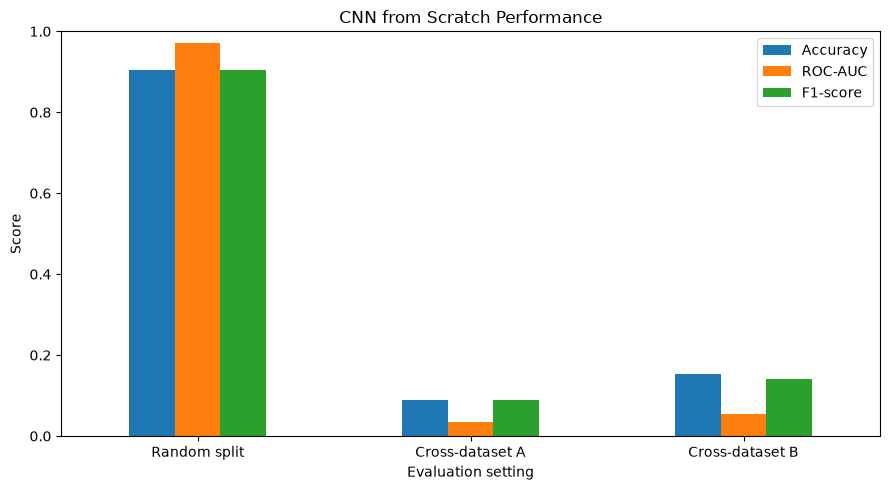

In [9]:
metric_plot_df = cnn_results[
    [
        "experiment",
        "accuracy",
        "auc",
        "f1_macro",
    ]
].copy()

metric_plot_df["experiment"] = metric_plot_df["experiment"].replace(
    {
        "cnn_scratch_random": "Random split",
        "cnn_scratch_cross_a": "Cross-dataset A",
        "cnn_scratch_cross_b": "Cross-dataset B",
    }
)

ax = metric_plot_df.set_index("experiment")[
    [
        "accuracy",
        "auc",
        "f1_macro",
    ]
].plot(
    kind="bar",
    figsize=(9, 5),
    rot=0,
)

ax.set_title("CNN from Scratch Performance")
ax.set_xlabel("Evaluation setting")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(
    [
        "Accuracy",
        "ROC-AUC",
        "F1-score",
    ]
)

plt.tight_layout()
plt.savefig(
    REPORTS_DIR / "cnn_scratch_metric_comparison.png",
    dpi=150,
)
plt.show()

In [10]:
random_row = cnn_results[
    cnn_results["experiment"] == "cnn_scratch_random"
].iloc[0]

cross_rows = cnn_results[
    cnn_results["experiment"].isin(
        [
            "cnn_scratch_cross_a",
            "cnn_scratch_cross_b",
        ]
    )
]

generalization_gap = pd.DataFrame(
    [
        {
            "metric": "accuracy",
            "random_split": random_row["accuracy"],
            "cross_dataset_mean": cross_rows["accuracy"].mean(),
            "generalization_gap": random_row["accuracy"] - cross_rows["accuracy"].mean(),
        },
        {
            "metric": "auc",
            "random_split": random_row["auc"],
            "cross_dataset_mean": cross_rows["auc"].mean(),
            "generalization_gap": random_row["auc"] - cross_rows["auc"].mean(),
        },
        {
            "metric": "f1_macro",
            "random_split": random_row["f1_macro"],
            "cross_dataset_mean": cross_rows["f1_macro"].mean(),
            "generalization_gap": random_row["f1_macro"] - cross_rows["f1_macro"].mean(),
        },
    ]
)

generalization_gap

,metric,random_split,cross_dataset_mean,generalization_gap
0,accuracy,0.9043,0.12215,0.78215
1,auc,0.9706,0.04445,0.92615
2,f1_macro,0.9042,0.11520,0.78900


### Generalization Gap

The difference between random split performance and cross-dataset performance is treated as the generalization gap.

For the CNN from scratch, this gap is very large. The model achieves high performance when training and test data come from the same mixture of source datasets, but fails when evaluated on unseen sources.

This indicates that the model has learned visual patterns that are useful within the training distribution but are not stable across dataset sources.

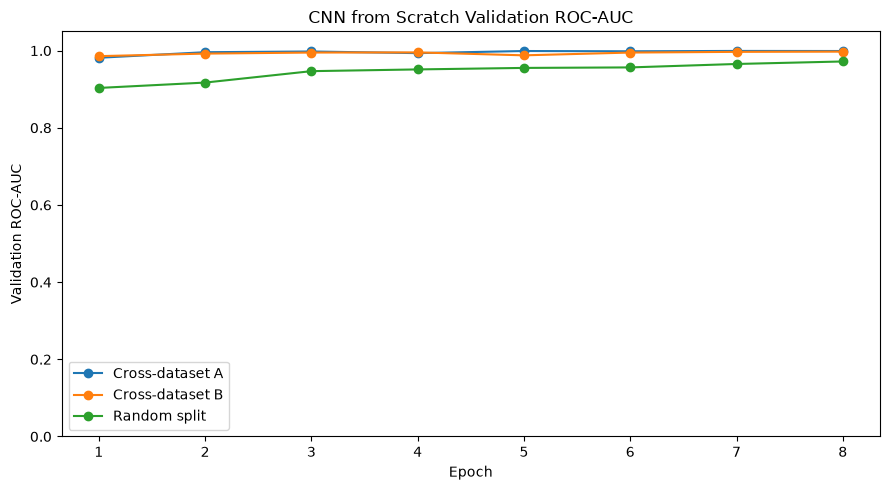

In [11]:
history_plot_df = cnn_history.copy()

history_plot_df["experiment_label"] = history_plot_df["experiment"].replace(
    {
        "cnn_scratch_random": "Random split",
        "cnn_scratch_cross_a": "Cross-dataset A",
        "cnn_scratch_cross_b": "Cross-dataset B",
    }
)

fig, ax = plt.subplots(figsize=(9, 5))

for experiment_label, group_df in history_plot_df.groupby("experiment_label"):
    group_df = group_df.sort_values("epoch")
    ax.plot(
        group_df["epoch"],
        group_df["val_auc"],
        marker="o",
        label=experiment_label,
    )

ax.set_title("CNN from Scratch Validation ROC-AUC")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation ROC-AUC")
ax.set_ylim(0, 1.05)
ax.legend()

plt.tight_layout()
plt.savefig(
    REPORTS_DIR / "cnn_scratch_validation_auc_curves.png",
    dpi=150,
)
plt.show()

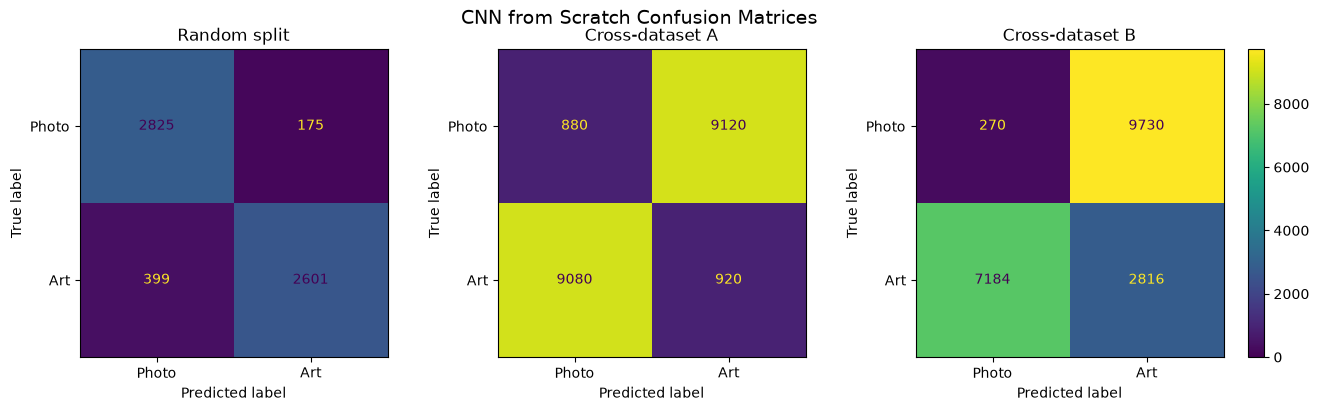

In [12]:
experiment_labels = {
    "cnn_scratch_random": "Random split",
    "cnn_scratch_cross_a": "Cross-dataset A",
    "cnn_scratch_cross_b": "Cross-dataset B",
}

max_count = 0

for experiment in experiment_labels:
    experiment_predictions = cnn_predictions[
        cnn_predictions["experiment"] == experiment
    ].copy()

    cm = confusion_matrix(
        experiment_predictions["y_true"],
        experiment_predictions["y_pred"],
        labels=[0, 1],
    )

    max_count = max(max_count, cm.max())

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4),
)

last_display = None

for ax, (experiment, experiment_label) in zip(
    axes,
    experiment_labels.items(),
):
    experiment_predictions = cnn_predictions[
        cnn_predictions["experiment"] == experiment
    ].copy()

    cm = confusion_matrix(
        experiment_predictions["y_true"],
        experiment_predictions["y_pred"],
        labels=[0, 1],
    )

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Photo",
            "Art",
        ],
    )

    display.plot(
        ax=ax,
        values_format="d",
        colorbar=False,
        im_kw={
            "vmin": 0,
            "vmax": max_count,
        },
    )

    ax.set_title(experiment_label)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    last_display = display

fig.suptitle(
    "CNN from Scratch Confusion Matrices",
    fontsize=14,
)

fig.colorbar(
    last_display.im_,
    ax=axes,
    fraction=0.025,
    pad=0.02,
)

plt.savefig(
    REPORTS_DIR / "cnn_scratch_confusion_matrices.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

### Sanity Check: Inverted Cross-Dataset Signal

The cross-dataset ROC-AUC values are far below 0.5. This does not simply indicate random failure. Instead, it suggests that the model has learned an inverted source-dependent signal.

If the model were only guessing randomly, the expected ROC-AUC would be close to 0.5. However, ROC-AUC values close to 0 indicate that the model ranks the two classes in the wrong direction on unseen sources.

To verify this behaviour, the predictions are inverted for the two cross-dataset experiments. If the inverted predictions achieve high performance, this supports the interpretation that the model has learned a systematic but non-transferable source-specific signal rather than a stable art-versus-photo representation.

In [13]:
inversion_rows = []

for experiment in [
    "cnn_scratch_cross_a",
    "cnn_scratch_cross_b",
]:
    experiment_predictions = cnn_predictions[
        cnn_predictions["experiment"] == experiment
    ].copy()

    y_true = experiment_predictions["y_true"].to_numpy()
    y_pred = experiment_predictions["y_pred"].to_numpy()
    y_proba = experiment_predictions["y_proba_art"].to_numpy()

    inverted_y_pred = 1 - y_pred
    inverted_y_proba = 1 - y_proba

    inversion_rows.append(
        {
            "experiment": experiment,
            "original_accuracy": accuracy_score(y_true, y_pred),
            "original_auc": roc_auc_score(y_true, y_proba),
            "original_f1_macro": f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            ),
            "inverted_accuracy": accuracy_score(y_true, inverted_y_pred),
            "inverted_auc": roc_auc_score(y_true, inverted_y_proba),
            "inverted_f1_macro": f1_score(
                y_true,
                inverted_y_pred,
                average="macro",
                zero_division=0,
            ),
        }
    )

cnn_inversion_check = pd.DataFrame(inversion_rows)

cnn_inversion_check[
    [
        "experiment",
        "original_accuracy",
        "original_auc",
        "original_f1_macro",
        "inverted_accuracy",
        "inverted_auc",
        "inverted_f1_macro",
    ]
]

,experiment,original_accuracy,original_auc,original_f1_macro,inverted_accuracy,inverted_auc,inverted_f1_macro
0,cnn_scratch_cross_a,0.0900,0.033815,0.089996,0.9100,0.966185,0.910000
1,cnn_scratch_cross_b,0.1543,0.055073,0.140369,0.8457,0.944927,0.843158


The inversion check shows that the cross-dataset failure is systematic rather than random. When the predictions are inverted, performance becomes high. This confirms that the model has learned a strong but reversed signal on unseen datasets.

This is consistent with the metadata diagnostic. In both cases, the model appears to rely on source-dependent patterns that are correlated with the target label in the training sources but reverse in the test sources.

For image-based CNNs, this signal may come from visual artefacts that remain after resizing, such as sharpness, compression patterns, upscaling artefacts, dataset-specific preprocessing, borders, texture statistics, or differences between native image resolutions.

Therefore, the cross-dataset CNN result should not be interpreted as a simple training failure. It is evidence that the model learns a non-transferable source-domain representation.

### Checkpoint Inference Demo

The main experiments are executed through external training scripts because full deep learning training is computationally expensive. However, the trained CNN checkpoint can still be loaded inside the notebook for a small inference demonstration.

This cell loads the best random-split CNN checkpoint and applies it to a small number of test images. The purpose is to demonstrate that the saved model artefact can be reused for inference, not to retrain the model inside the notebook.

### Potential Dataset Overlap

A possible limitation of the cross-dataset setup is the potential overlap between WikiArt and ArtBench. ArtBench is an art dataset that may contain images or near-duplicates originating from sources similar to WikiArt. Therefore, the art side of the cross-dataset split may not be perfectly independent.

This does not invalidate the experiment, because the photo datasets and the full source-domain structure are still different. However, it means that the term "unseen source" should be interpreted at the dataset-source level rather than as a guarantee of complete image-level independence.

A stronger future version of the project would include perceptual hash-based near-duplicate detection across all datasets before creating the final splits.

### Checkpoint Inference Demo

The main experiments are executed through external training scripts because full deep learning training is computationally expensive. However, the trained CNN checkpoint can still be loaded inside the notebook for a small inference demonstration.

This cell loads the best random-split CNN checkpoint and applies it to a small number of test images. The purpose is to demonstrate that the saved model artefact can be reused for inference, not to retrain the model inside the notebook.

In [14]:
PROJECT_ROOT = Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

if "cnn_predictions" not in globals():
    cnn_predictions = pd.read_csv(
        PROCESSED_DIR / "cnn_scratch_predictions.csv"
    )


class VisualStyleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)

        return x.squeeze(1)


def resolve_image_path(image_path: str) -> Path:
    path = Path(image_path)

    if path.is_absolute():
        return path

    return PROJECT_ROOT / path


checkpoint_path = MODELS_DIR / "cnn_scratch_random_best.pt"

inference_transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ]
)

if checkpoint_path.exists():
    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    try:
        checkpoint = torch.load(
            checkpoint_path,
            map_location=device,
            weights_only=False,
        )
    except TypeError:
        checkpoint = torch.load(
            checkpoint_path,
            map_location=device,
        )

    demo_model = VisualStyleCNN().to(device)
    demo_model.load_state_dict(checkpoint["model_state_dict"])
    demo_model.eval()

    demo_images = (
        cnn_predictions[
            cnn_predictions["experiment"] == "cnn_scratch_random"
        ]
        .groupby("class_name", group_keys=False)
        .head(3)
        .copy()
    )

    demo_rows = []

    for _, row in demo_images.iterrows():
        image_path = resolve_image_path(row["image_path"])
        image = Image.open(image_path).convert("RGB")

        image_tensor = inference_transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            logit = demo_model(image_tensor)
            probability_art = torch.sigmoid(logit).item()

        predicted_label = int(probability_art >= 0.5)
        predicted_class = "art" if predicted_label == 1 else "photo"

        demo_rows.append(
            {
                "image_path": row["image_path"],
                "true_class": row["class_name"],
                "predicted_class": predicted_class,
                "probability_art": probability_art,
            }
        )

    cnn_checkpoint_demo = pd.DataFrame(demo_rows)

else:
    cnn_checkpoint_demo = pd.DataFrame(
        [
            {
                "status": "Checkpoint not found locally. The notebook can still reproduce the analysis from the saved CSV outputs.",
                "expected_checkpoint": str(checkpoint_path),
            }
        ]
    )

cnn_checkpoint_demo

,image_path,true_class,predicted_class,probability_art
0,data\raw\coco_subset\train2017\000000319738.jpg,photo,photo,0.188765
1,data\raw\places365\val_256\Places365_val_00011...,photo,photo,0.166860
2,data\raw\artbench\artbench-10-imagefolder-spli...,art,art,0.578125
3,data\raw\places365\val_256\Places365_val_00022...,photo,photo,0.300918
4,data\raw\artbench\artbench-10-imagefolder-spli...,art,art,0.588423
5,data\raw\artbench\artbench-10-imagefolder-spli...,art,art,0.630460


### Interpretation

The CNN from scratch baseline confirms the main concern raised by the metadata diagnostic.

Under the random split, the model achieves high performance. This could initially suggest that the model has learned a strong art-versus-photo representation. However, the cross-dataset experiments show that this interpretation would be misleading.

When the model is evaluated on unseen source datasets, performance collapses. This means that the learned visual representation does not generalize reliably across sources.

The result is important because the CNN does not receive explicit metadata features. Source-domain effects can still influence pixel-based deep learning models after resizing images to a common input resolution.

The CNN baseline therefore provides a bridge between the metadata-only diagnostic and the transfer learning experiments. The next step is to evaluate whether pretrained visual representations from ResNet18 are more robust under the same cross-dataset evaluation design.

## Transfer Learning with ResNet18

The second modelling approach uses transfer learning with ResNet18. ResNet18 is a convolutional neural network architecture pretrained on a large-scale image dataset. Instead of learning all visual features from scratch, the model starts from general-purpose visual representations that already capture edges, textures, shapes, object parts, and scene-level patterns.

Transfer learning is especially useful when the project dataset is smaller than the datasets used to train large modern computer vision models. In this project, ResNet18 is used as the main transfer learning model because it is relatively lightweight, well understood, and suitable for a course-level deep learning project.

Two transfer learning strategies are evaluated.

### ResNet18 Freeze

In the freeze strategy, the pretrained ResNet18 backbone is kept fixed and only the final classification head is trained. This tests whether general pretrained visual features are already sufficient for art-versus-photo classification.

This strategy has several advantages:

| Advantage              | Explanation                                     |
| ---------------------- | ----------------------------------------------- |
| Faster training        | Only a small number of parameters are updated   |
| Lower overfitting risk | Most pretrained weights remain unchanged        |
| Strong baseline        | Tests the usefulness of generic visual features |

However, the frozen model may not adapt deeply enough to the specific visual differences between artistic and photographic images.

### ResNet18 Full Fine-Tuning

In the full fine-tuning strategy, the entire ResNet18 model is trained on the project dataset. This allows the pretrained visual representations to adapt to the art-versus-photo task.

This strategy can potentially improve performance because the model is allowed to learn more task-specific visual patterns. However, it also introduces a higher risk of overfitting, especially if the model learns source-specific artefacts instead of transferable visual structure.

The comparison between frozen transfer learning and full fine-tuning helps answer the following question:

**Does adapting the entire pretrained model improve cross-dataset generalization, or does it mainly improve closed-domain random split performance?**

## Evaluation Metrics

The project evaluates all models using multiple metrics rather than relying on accuracy alone. This is important because accuracy may hide differences in error patterns, class behaviour, and ranking quality.

The main metrics are:

| Metric           | Meaning                                             |
| ---------------- | --------------------------------------------------- |
| Accuracy         | Percentage of correctly classified images           |
| ROC-AUC          | Ability to separate art and photo across thresholds |
| Precision        | How reliable positive predictions are               |
| Recall           | How many true positives are found                   |
| F1-score         | Balance between precision and recall                |
| Confusion matrix | Detailed view of correct and incorrect predictions  |

ROC-AUC is treated as one of the most important metrics because it evaluates how well the model ranks art images above photo images independently of a fixed decision threshold.

Confusion matrices are used to inspect the direction of mistakes. For example, a high number of artworks predicted as photos may indicate that some artistic images are visually close to photographic content, while many photos predicted as art may indicate that stylized photography overlaps with artistic visual structure.

## Experimental Evaluation Strategy

The project does not rely on a single random train-test split. Because the metadata diagnostic revealed strong source-domain signal, model evaluation is divided into two levels.

### Closed-Domain Evaluation

The random stratified split mixes all four source datasets while preserving balance by class and source. This provides a standard benchmark where the model is trained and tested on images drawn from the same overall source distribution.

This setting answers:

**How well does the model perform when all source datasets are represented in both training and test data?**

### Cross-Dataset Evaluation

The cross-dataset splits intentionally separate training and testing sources. This creates a stricter evaluation setting where the model must generalize to unseen source datasets.

Cross-dataset split A:

| Role             | Sources             |
| ---------------- | ------------------- |
| Train/validation | WikiArt + Places365 |
| Test             | ArtBench + COCO     |

Cross-dataset split B:

| Role             | Sources             |
| ---------------- | ------------------- |
| Train/validation | ArtBench + COCO     |
| Test             | WikiArt + Places365 |

These experiments answer:

**Does the model learn transferable visual representations, or does it depend mainly on source-specific patterns?**

The difference between random split performance and cross-dataset performance is treated as a generalization gap. A large drop in performance suggests that the model may rely on dataset-specific visual or technical patterns. A smaller drop suggests stronger cross-domain generalization.
